# Full HCM Framework Test

End-to-end test of the three HCM graph types from Weinstein & Blei (2023):

| # | Model | Graph | Identification |
|---|-------|-------|----------------|
| 1 | **CONFOUNDER** | U→A, U→Y, A→Y | backdoor via Q^{y\|a} |
| 2 | **CONFOUNDER & INTERFERENCE** | U→A, U→Y, A→Y, A→Z, Z→Y | front-door via Z |
| 3 | **INSTRUMENT** | U→A, U→Y, Z→A, A→Y | IV via Q^{a\|z} |

Pipeline per model:
1. Define `HSCMParametric` for **graph structure only** (no sample_data)
2. Generate data via **direct NumPy DGP**
3. `collapse()` → `augment_collapsed_model()` → `marginalize_augmented_model()` (INSTRUMENT only)
4. `identify_effect()` → symbolic identification formula
5. `estimate_causal_effect()` → **formula-driven dispatch**: the identified ASTree is analysed  
   (`_analyze_formula`) to select the optimal paper estimator (Appendix D) automatically —  
   no heuristic key-name matching; the formula structure is the ground truth
6. Compare against true ATE (Monte Carlo over unobserved U)

In [ ]:
import sys
sys.path.insert(0, '.')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from hierarchicalcausalmodels.models import HSCMParametric
from do_calculus import (
    collapse,
    augment_collapsed_model,
    marginalize_augmented_model,
    suggest_augment_for_outcome,
    identify_effect,
    PYAGNUM_AVAILABLE,
)
from estimation import (
    estimate_causal_effect,                  # primary API — formula-driven dispatch
    estimate_confounder_ate,                 # Appendix D.1 standalone
    estimate_confounder_interference_ate,    # Appendix D.2 standalone
    estimate_instrument_ate,                 # Appendix D.3 standalone
    SubunitParamEstimator,
    QDensityEstimator,
    PerUnitQEstimator,
)

rng = np.random.default_rng(42)

N_UNITS = 200    # more units → lower estimation variance
N_SUB   = 50
SIZES   = [N_SUB] * N_UNITS

print(f'pyAgrum available: {PYAGNUM_AVAILABLE}')
print(f'Units: {N_UNITS},  subunits/unit: {N_SUB}')

In [2]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def plot_cgm(cgm, title, ax, highlight_unobs=None, pos=None):
    G = cgm.dag
    if pos is None:
        pos = nx.spring_layout(G, seed=0, k=2)
    unobs = getattr(cgm, 'unobserved_variables', set()) or set()
    if highlight_unobs:
        unobs = unobs | set(highlight_unobs)
    node_colors = ['#f4a460' if n in unobs else '#aec6cf' for n in G.nodes]
    nx.draw_networkx(
        G, pos, ax=ax,
        node_color=node_colors, node_size=1400,
        font_size=8, font_weight='bold',
        edge_color='#555', arrows=True,
        arrowsize=18, arrowstyle='-|>',
        connectionstyle='arc3,rad=0.05',
    )
    ax.set_title(title, fontsize=11, pad=8)
    ax.axis('off')
    obs_p   = mpatches.Patch(color='#aec6cf', label='observed')
    unobs_p = mpatches.Patch(color='#f4a460', label='unobserved')
    ax.legend(handles=[obs_p, unobs_p], fontsize=7, loc='lower right')
    return pos

print('Helpers defined.')

Helpers defined.


---
## 1 — CONFOUNDER model  (paper Fig. 2a)

**Graph**: U → A, U → Y, A → Y  (A, Y subunit-level; U unit-level, **unobserved**)

**DGP**:
$$U_i \sim \text{Beta}(2,2), \quad A_{ij}\mid U_i \sim \text{Bern}(U_i), \quad Y_{ij}\mid A_{ij},U_i \sim \text{Bern}\bigl(\sigma(1.5\,A + U - 0.5)\bigr)$$

**Identification**: back-door adjustment via the unit-level Q-variables $Q^a_i, Q^{y|a}_i$.

In [3]:
# ── 1.1  Define HSCMParametric (graph structure only) ────────────────────────
def _noop(d): return None

hscm_conf = HSCMParametric(
    nodes={'U', 'A', 'Y'},
    edges={('U','A'), ('U','Y'), ('A','Y')},
    unit_nodes={'U'},
    subunit_nodes={'A', 'Y'},
    sizes=SIZES,
    node_functions={'U': _noop, 'A': _noop, 'Y': _noop},
    data={},
)
hscm_conf.cgm.unobserved_variables = {'U'}
hscm_conf.cgm.observed_variables   = {'A', 'Y'}
print('CONFOUNDER graph defined:', sorted(hscm_conf.cgm.dag.nodes))

CONFOUNDER graph defined: ['U', '_A', '_Y']


U: (200,),  A: (200, 50),  Y: (200, 50)
Mean A: 0.504,  Mean Y: 0.660


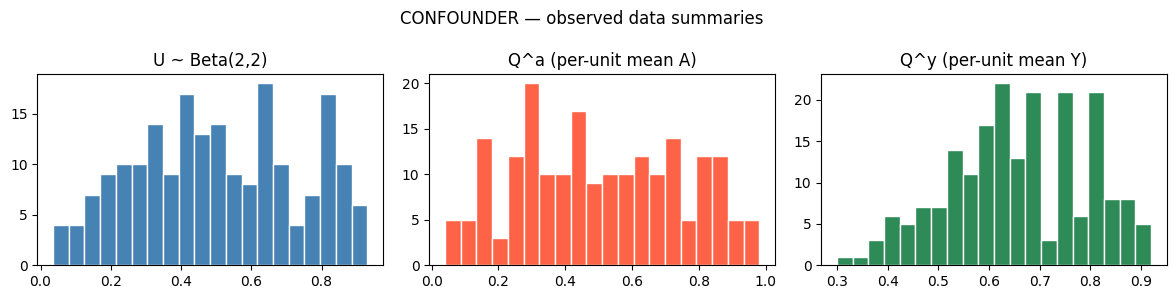

In [4]:
# ── 1.2  Generate data via direct NumPy DGP ──────────────────────────────────
# U_i ~ Beta(2,2)
U_conf = rng.beta(2, 2, N_UNITS)

# A_ij | U_i ~ Bern(U_i)
A_conf = np.array([
    rng.binomial(1, np.clip(U_conf[i], 0, 1), N_SUB)
    for i in range(N_UNITS)
], dtype=float)

# Y_ij | A_ij, U_i ~ Bern(sigmoid(1.5*A + U - 0.5))
Y_conf = np.array([
    rng.binomial(1, np.clip(sigmoid(1.5*A_conf[i] + U_conf[i] - 0.5), 0, 1))
    for i in range(N_UNITS)
], dtype=float)

print(f'U: {U_conf.shape},  A: {A_conf.shape},  Y: {Y_conf.shape}')
print(f'Mean A: {A_conf.mean():.3f},  Mean Y: {Y_conf.mean():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(U_conf,          bins=20, color='steelblue', edgecolor='w'); axes[0].set(title='U ~ Beta(2,2)')
axes[1].hist(A_conf.mean(1),  bins=20, color='tomato',    edgecolor='w'); axes[1].set(title='Q^a (per-unit mean A)')
axes[2].hist(Y_conf.mean(1),  bins=20, color='seagreen',  edgecolor='w'); axes[2].set(title='Q^y (per-unit mean Y)')
plt.suptitle('CONFOUNDER — observed data summaries', fontsize=12)
plt.tight_layout(); plt.show()

Collapsed  nodes: ['Q^a', 'Q^{y|a}', 'U']
Collapsed  edges: [('U', 'Q^a'), ('U', 'Q^{y|a}')]
Augmented  nodes: ['Q^a', 'Q^y', 'Q^{y|a}', 'U']
Augmented  edges: [('Q^a', 'Q^y'), ('Q^{y|a}', 'Q^y'), ('U', 'Q^a'), ('U', 'Q^{y|a}')]


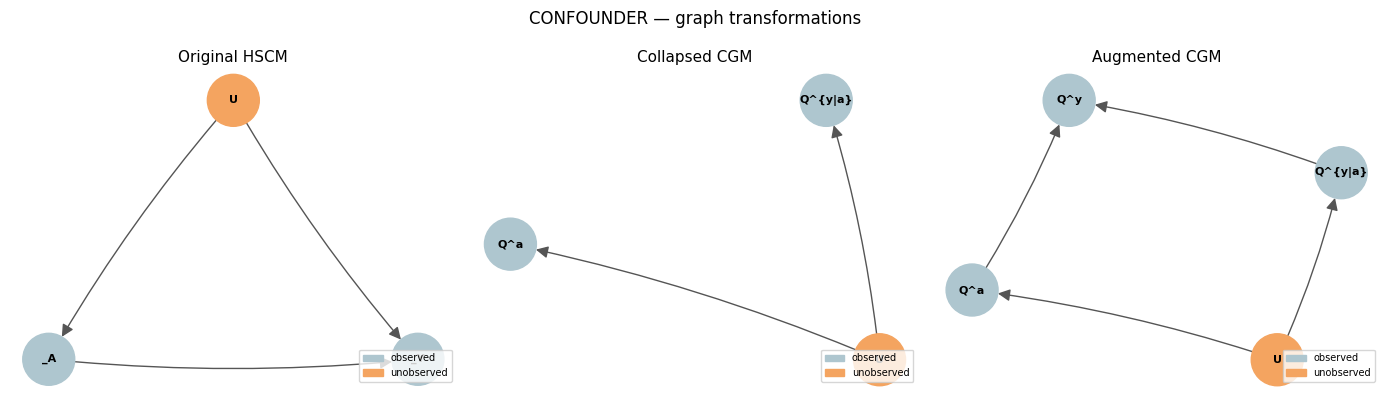

In [5]:
# ── 1.3  Collapse → Augment ──────────────────────────────────────────────────
conf_cgm     = collapse(hscm_conf)
conf_aug_cgm = augment_collapsed_model(conf_cgm, 'Q^y', {'Q^{y|a}', 'Q^a'})
conf_aug_cgm.unobserved_variables = {'U'}

print('Collapsed  nodes:', sorted(conf_cgm.dag.nodes))
print('Collapsed  edges:', sorted(conf_cgm.dag.edges))
print('Augmented  nodes:', sorted(conf_aug_cgm.dag.nodes))
print('Augmented  edges:', sorted(conf_aug_cgm.dag.edges))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# internal HSCM DAG uses '_A', '_Y' for subunit nodes
pos_h = {'U': (0, 1), '_A': (-1, 0), '_Y': (1, 0)}
plot_cgm(hscm_conf.cgm, 'Original HSCM', axes[0], highlight_unobs={'U'}, pos=pos_h)
plot_cgm(conf_cgm,      'Collapsed CGM', axes[1], highlight_unobs={'U'})
plot_cgm(conf_aug_cgm,  'Augmented CGM', axes[2], highlight_unobs={'U'})
plt.suptitle('CONFOUNDER — graph transformations', fontsize=12)
plt.tight_layout(); plt.show()

In [6]:
# ── 1.4  Do-calculus identification ─────────────────────────────────────────
result_conf = identify_effect(
    conf_aug_cgm, Y={'Q^y'}, X={'Q^a'}, unobserved={'U'}
)
print('Identifiable:', result_conf.identifiable)
if result_conf.formula_latex:
    print('Formula:', result_conf.formula_latex)

Identifiable: True
Formula: \sum_{Qy_a}{P\left(Qy_a\right) \cdot P\left(Qy\mid Qa,Qy_a\right)}


In [7]:
# ── 1.5  True ATE via Monte Carlo ───────────────────────────────────────────
# E[Y|do(A=a)] = E_U[sigmoid(1.5*a + U - 0.5)]
U_mc = rng.beta(2, 2, 200_000)
true_ey1_conf = float(np.mean(sigmoid(1.5*1 + U_mc - 0.5)))
true_ey0_conf = float(np.mean(sigmoid(1.5*0 + U_mc - 0.5)))
true_ate_conf = true_ey1_conf - true_ey0_conf
print(f'True E[Y|do(A=1)] = {true_ey1_conf:.4f}')
print(f'True E[Y|do(A=0)] = {true_ey0_conf:.4f}')
print(f'True ATE          = {true_ate_conf:.4f}')

True E[Y|do(A=1)] = 0.8153
True E[Y|do(A=0)] = 0.5001
True ATE          = 0.3152


In [ ]:
# ── 1.6  Estimate ATE ────────────────────────────────────────────────────────

# Method A: standalone per-unit estimator (explicit call)
ate1_conf_s = estimate_confounder_ate(Y_conf, A_conf, 1.0, family='bernoulli')
ate0_conf_s = estimate_confounder_ate(Y_conf, A_conf, 0.0, family='bernoulli')
effect_conf_s = ate1_conf_s - ate0_conf_s

# Method B: full pipeline via estimate_causal_effect
# The identified formula \sum_{Qy_a} P(Qy_a)·P(Qy|Qa,Qy_a) is parsed by
# _analyze_formula → pattern='confounder' → dispatches to estimate_confounder_ate
# (PerUnitQEstimator, Appendix D.1). 2D A and Y arrays are required.
data_conf = {
    'A': A_conf,    # (200, 50) subunit treatment
    'Y': Y_conf,    # (200, 50) subunit outcome
}

ate1_conf_f = estimate_causal_effect(
    result_conf, data=data_conf, intervention={'Q^a': 1.0},
    distribution_families={'A': 'bernoulli', 'Y': 'bernoulli'},
)
ate0_conf_f = estimate_causal_effect(
    result_conf, data=data_conf, intervention={'Q^a': 0.0},
    distribution_families={'A': 'bernoulli', 'Y': 'bernoulli'},
)
effect_conf_f = ate1_conf_f - ate0_conf_f

hdr = '{:<30} {:>12} {:>12} {:>10} {:>10}'.format('Method','E[Y|do(1)]','E[Y|do(0)]','ATE','Error')
sep = '-' * 78
print('CONFOUNDER — ATE estimation results')
print(hdr); print(sep)
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10}'.format('True (MC)', true_ey1_conf, true_ey0_conf, true_ate_conf, '—'))
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10.4f}'.format('Standalone', ate1_conf_s, ate0_conf_s, effect_conf_s, abs(effect_conf_s-true_ate_conf)))
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10.4f}'.format('estimate_causal_effect', ate1_conf_f, ate0_conf_f, effect_conf_f, abs(effect_conf_f-true_ate_conf)))

---
## 2 — CONFOUNDER & INTERFERENCE model  (paper Fig. 2e)

**Graph**: U→A, U→Y, A→Y, A→Z, Z→Y  (A, Y subunit-level; U, Z unit-level; U **unobserved**)

**DGP**:
$$U_i \sim \text{Beta}(2,2), \quad A_{ij}\mid U_i \sim \text{Bern}(U_i)$$
$$Z_i \mid Q^a_i \sim \text{Bern}\bigl(\sigma(2Q^a_i - 1)\bigr)$$
$$Y_{ij}\mid A_{ij},Z_i,U_i \sim \text{Bern}\bigl(\sigma(1.5\,A + Z + 0.3\,U - 0.5)\bigr)$$

**Identification**: front-door adjustment through unit-level mediator $Z_i$.

In [9]:
# ── 2.1  Define HSCMParametric (graph structure only) ────────────────────────
hscm_ci = HSCMParametric(
    nodes={'U', 'Z', 'A', 'Y'},
    edges={('U','A'), ('U','Y'), ('A','Y'), ('A','Z'), ('Z','Y')},
    unit_nodes={'U', 'Z'},
    subunit_nodes={'A', 'Y'},
    sizes=SIZES,
    node_functions={'U': _noop, 'Z': _noop, 'A': _noop, 'Y': _noop},
    data={},
)
hscm_ci.cgm.unobserved_variables = {'U'}
hscm_ci.cgm.observed_variables   = {'Z', 'A', 'Y'}
print('C&I graph defined:', sorted(hscm_ci.cgm.dag.nodes))

C&I graph defined: ['U', 'Z', '_A', '_Y']


U: (200,), Z: (200,), A: (200, 50), Y: (200, 50)
Mean Z: 0.560,  Mean A: 0.527,  Mean Y: 0.694


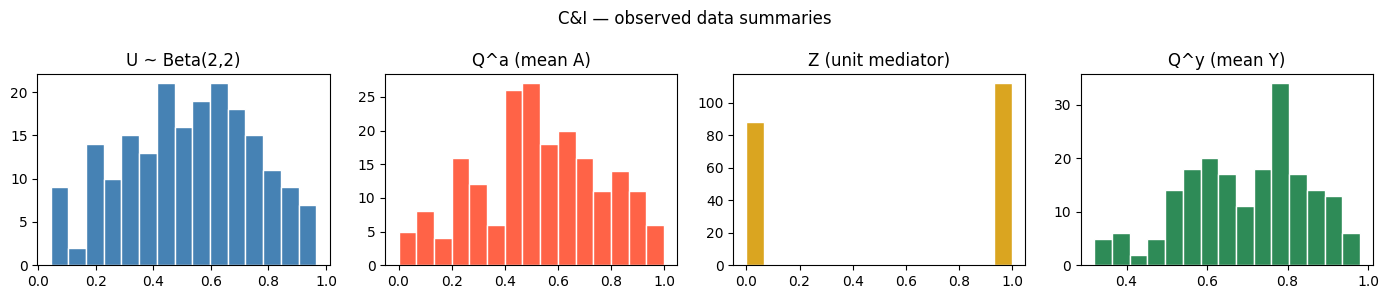

In [10]:
# ── 2.2  Generate data via direct NumPy DGP ──────────────────────────────────
# U_i ~ Beta(2,2)
U_ci = rng.beta(2, 2, N_UNITS)

# A_ij | U_i ~ Bern(U_i)
A_ci = np.array([
    rng.binomial(1, np.clip(U_ci[i], 0, 1), N_SUB)
    for i in range(N_UNITS)
], dtype=float)

# Q^a_i = mean(A_ij) — unit-level treatment rate
Q_a_ci_obs = A_ci.mean(axis=1)

# Z_i | Q^a_i ~ Bern(sigmoid(2*Q^a - 1))  [no U→Z edge]
Z_ci = rng.binomial(1, np.clip(sigmoid(2*Q_a_ci_obs - 1), 0, 1)).astype(float)

# Y_ij | A_ij, Z_i, U_i ~ Bern(sigmoid(1.5*A + Z + 0.3*U - 0.5))
Y_ci = np.array([
    rng.binomial(1, np.clip(sigmoid(1.5*A_ci[i] + Z_ci[i] + 0.3*U_ci[i] - 0.5), 0, 1))
    for i in range(N_UNITS)
], dtype=float)

print(f'U: {U_ci.shape}, Z: {Z_ci.shape}, A: {A_ci.shape}, Y: {Y_ci.shape}')
print(f'Mean Z: {Z_ci.mean():.3f},  Mean A: {A_ci.mean():.3f},  Mean Y: {Y_ci.mean():.3f}')

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (arr, label, color) in zip(axes, [
    (U_ci,          'U ~ Beta(2,2)',      'steelblue'),
    (Q_a_ci_obs,    'Q^a (mean A)',       'tomato'),
    (Z_ci,          'Z (unit mediator)',  'goldenrod'),
    (Y_ci.mean(1),  'Q^y (mean Y)',       'seagreen'),
]):
    ax.hist(arr, bins=15, color=color, edgecolor='w')
    ax.set(title=label)
plt.suptitle('C&I — observed data summaries', fontsize=12)
plt.tight_layout(); plt.show()

Collapsed  nodes: ['Q^a', 'Q^{y|a}', 'U', 'Z']
Collapsed  edges: [('Q^a', 'Z'), ('U', 'Q^a'), ('U', 'Q^{y|a}'), ('Z', 'Q^{y|a}')]


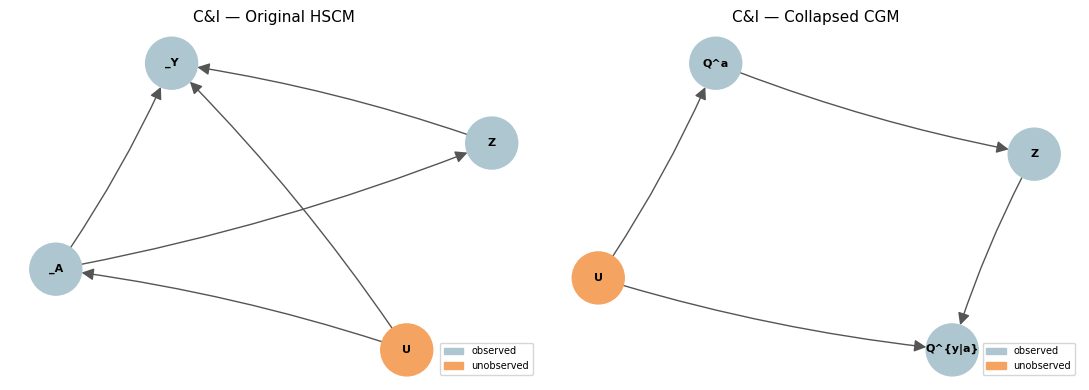

In [11]:
# ── 2.3  Collapse only (no augmentation for C&I) ─────────────────────────────
# Front-door identification goes through the observed unit mediator Z in the
# collapsed graph — augmenting Q^y would introduce a cycle.
ci_cgm = collapse(hscm_ci)
ci_cgm.unobserved_variables = {'U'}

print('Collapsed  nodes:', sorted(ci_cgm.dag.nodes))
print('Collapsed  edges:', sorted(ci_cgm.dag.edges))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_cgm(hscm_ci.cgm, 'C&I — Original HSCM', axes[0], highlight_unobs={'U'})
plot_cgm(ci_cgm,      'C&I — Collapsed CGM',  axes[1], highlight_unobs={'U'})
plt.tight_layout(); plt.show()

In [12]:
# ── 2.4  Do-calculus identification on collapsed graph ────────────────────────
# After collapse: nodes = {U, Z, Q^a, Q^{y|a}}; edges = {U→Q^a, U→Q^{y|a}, Q^a→Z, Z→Q^{y|a}}
# Front-door through Z: P(Q^{y|a}|do(Q^a)) = Σ_z P(Z|Q^a) * Σ_{q'} P(Q^{y|a}|q',z) P(q')
result_ci = identify_effect(
    ci_cgm, Y={'Q^{y|a}'}, X={'Q^a'}, unobserved={'U'}
)
print('Identifiable:', result_ci.identifiable)
if result_ci.formula_latex:
    print('Formula:', result_ci.formula_latex)

Identifiable: True
Formula: \sum_{Z}{P\left(Z\mid Qa\right) \cdot \left(\sum_{Qa}{P\left(Qy_a\mid Qa,Z\right) \cdot P\left(Qa\right)}\right)}


In [13]:
# ── 2.5  True ATE via Monte Carlo ────────────────────────────────────────────
# Under do(A=a):
#   Z_i ~ Bern(sigmoid(2*a - 1))  — fixed at intervention value
#   E[Y|do(A=a)] = E_U[ p_z * E[Y|A=a,Z=1,U] + (1-p_z)*E[Y|A=a,Z=0,U] ]
U_mc_ci = rng.beta(2, 2, 200_000)

def true_ey_ci(a_val):
    p_z  = sigmoid(2*a_val - 1)   # Z ~ Bern(p_z), independent of U
    ey_z1 = sigmoid(1.5*a_val + 1 + 0.3*U_mc_ci - 0.5)
    ey_z0 = sigmoid(1.5*a_val + 0 + 0.3*U_mc_ci - 0.5)
    return float(np.mean(p_z * ey_z1 + (1 - p_z) * ey_z0))

true_ey1_ci = true_ey_ci(1)
true_ey0_ci = true_ey_ci(0)
true_ate_ci = true_ey1_ci - true_ey0_ci
print(f'True E[Y|do(A=1)] = {true_ey1_ci:.4f}')
print(f'True E[Y|do(A=0)] = {true_ey0_ci:.4f}')
print(f'True ATE          = {true_ate_ci:.4f}')

True E[Y|do(A=1)] = 0.8589
True E[Y|do(A=0)] = 0.4790
True ATE          = 0.3799


In [ ]:
# ── 2.6  Estimate ATE ────────────────────────────────────────────────────────

# Method A: standalone front-door estimator (explicit call)
ate1_ci_s = estimate_confounder_interference_ate(
    Y_ci, A_ci, Z_ci, intervention_value=1.0,
    family_outcome='bernoulli', family_mediator='bernoulli',
)
ate0_ci_s = estimate_confounder_interference_ate(
    Y_ci, A_ci, Z_ci, intervention_value=0.0,
    family_outcome='bernoulli', family_mediator='bernoulli',
)
effect_ci_s = ate1_ci_s - ate0_ci_s

# Method B: full pipeline via estimate_causal_effect
# The identified formula \sum_{Z} P(Z|Qa)·(\sum_{Qa} P(Qy_a|Qa,Z)·P(Qa)) is
# parsed by _analyze_formula → nested _ASTSum detected → pattern='ci' →
# dispatches to estimate_confounder_interference_ate (Appendix D.2).
# Requires 2D A + Y and 1D Z mediator.
Q_ya_ci = Y_ci.mean(axis=1)
data_ci = {
    'A': A_ci,           # (200, 50) subunit treatment
    'Y': Y_ci,           # (200, 50) subunit outcome
    'Z': Z_ci,           # (200,)    unit-level mediator
}

ate1_ci_f = estimate_causal_effect(
    result_ci, data=data_ci, intervention={'Q^a': 1.0},
    distribution_families={'A': 'bernoulli', 'Y': 'bernoulli', 'Z': 'bernoulli'},
)
ate0_ci_f = estimate_causal_effect(
    result_ci, data=data_ci, intervention={'Q^a': 0.0},
    distribution_families={'A': 'bernoulli', 'Y': 'bernoulli', 'Z': 'bernoulli'},
)
effect_ci_f = ate1_ci_f - ate0_ci_f

hdr = '{:<30} {:>12} {:>12} {:>10} {:>10}'.format('Method','E[Y|do(1)]','E[Y|do(0)]','ATE','Error')
sep = '-' * 78
print('CONFOUNDER & INTERFERENCE — ATE estimation results')
print(hdr); print(sep)
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10}'.format('True (MC)', true_ey1_ci, true_ey0_ci, true_ate_ci, '—'))
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10.4f}'.format('Standalone', ate1_ci_s, ate0_ci_s, effect_ci_s, abs(effect_ci_s-true_ate_ci)))
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10.4f}'.format('estimate_causal_effect', ate1_ci_f, ate0_ci_f, effect_ci_f, abs(effect_ci_f-true_ate_ci)))

---
## 3 — INSTRUMENT model  (paper Fig. 2i)

**Graph**: U→A, U→Y, Z→A, A→Y  (Z, A subunit-level; U, Y unit-level; U **unobserved**)

**DGP** (unit-level Q^z variation provides a genuine exogenous instrument):
$$U_i \sim \text{Beta}(2,2), \quad Q^z_i \sim \text{Beta}(2,2) \;\text{independent of } U_i, \quad Z_{ij} \mid Q^z_i \sim \text{Bern}(Q^z_i)$$
$$P(A_{ij}=1 \mid Z_{ij},U_i) = \text{clip}(0.40\,Z + 0.55\,U + 0.05,\;0,1)$$
$$Y_i \mid Q^a_i,U_i \sim \text{Bern}\bigl(\sigma(3\,Q^a_i + 1.5\,U_i - 1.5)\bigr)$$

**Pipeline**: collapse → augment Q^a with parents {Q^z, Q^{a|z}} → marginalize Q^z → identify P(Y|do(Q^a))

**Key**: because Q^z_i ~ Beta(2,2) varies **independently** of U_i across units,
$Q^a_i \approx 0.40\,Q^z_i + 0.55\,U_i + 0.05$ has genuine exogenous variation beyond
$Q^{a|z}_i \approx 0.45 + 0.55\,U_i$.
This reduces corr(Q^a, Q^{a|z}) from ≈ 0.90 (fixed Q^z = 0.5) to ≈ 0.62,
making the backdoor regression well-conditioned.

In [15]:
# ── 3.1  Define HSCMParametric (graph structure only) ────────────────────────
hscm_inst = HSCMParametric(
    nodes={'U', 'Y', 'Z', 'A'},
    edges={('U','A'), ('U','Y'), ('Z','A'), ('A','Y')},
    unit_nodes={'U', 'Y'},
    subunit_nodes={'Z', 'A'},
    sizes=SIZES,
    node_functions={'U': _noop, 'Y': _noop, 'Z': _noop, 'A': _noop},
    data={},
)
hscm_inst.cgm.unobserved_variables = {'U'}
hscm_inst.cgm.observed_variables   = {'Y', 'Z', 'A'}
print('INSTRUMENT graph defined:', sorted(hscm_inst.cgm.dag.nodes))

INSTRUMENT graph defined: ['U', 'Y', '_A', '_Z']


In [ ]:
# ── 3.2  Generate data via direct NumPy DGP ──────────────────────────────────
# U_i ~ Beta(2,2)  — unobserved unit-level confounder
U_inst = rng.beta(2, 2, N_UNITS)

# Q^z_i ~ Beta(2,2)  — unit-level Z propensity, INDEPENDENT of U
# Key: Q^z_i varies per unit, giving Q^a genuine exogenous variation beyond Q^{a|z}.
Q_z_inst = rng.beta(2, 2, N_UNITS)

# Z_ij | Q^z_i ~ Bern(Q^z_i)  — subunit instrument
Z_inst = rng.binomial(1, Q_z_inst[:, None] * np.ones(N_SUB)).astype(float)

# P(A=1 | Z,U) = clip(0.40*Z + 0.55*U + 0.05, 0, 1)
# → Q^a_i   ≈ 0.40·Q^z_i + 0.55·U_i + 0.05  (varies with both Q^z AND U)
# → Q^{a|z}_i ≈ 0.45 + 0.55·U_i              (varies with U only)
# corr(Q^a, Q^{a|z}) ≈ 0.62  (vs. ≈ 0.90 with fixed Q^z = 0.5)
pA_inst = np.clip(0.40*Z_inst + 0.55*U_inst[:, None] + 0.05, 0, 1)
A_inst = rng.binomial(1, pA_inst).astype(float)

# Q^a_i = mean(A_ij) — per-unit marginal treatment rate
Q_a_inst = A_inst.mean(axis=1)

# Q^{a|z}_i = E[A_ij | Z_ij=1]  — compliance rate (proxy for U)
Q_az_inst = np.array([
    A_inst[i][Z_inst[i] == 1].mean() if (Z_inst[i] == 1).any() else A_inst[i].mean()
    for i in range(N_UNITS)
])

# Y_i | Q^a_i, U_i ~ Bern(sigmoid(3·Q^a + 1.5·U - 1.5))  — unit-level outcome
Y_inst = rng.binomial(1, np.clip(sigmoid(3*Q_a_inst + 1.5*U_inst - 1.5), 0, 1)).astype(float)

print(f'U: {U_inst.shape}, Y: {Y_inst.shape}, Z: {Z_inst.shape}, A: {A_inst.shape}')
print(f'Mean A: {A_inst.mean():.3f},  Mean Y: {Y_inst.mean():.3f}')
print(f'Q^z  range: {Q_z_inst.min():.3f} - {Q_z_inst.max():.3f}  (unit propensity ~ Beta(2,2))')
print(f'Q^az range: {Q_az_inst.min():.3f} - {Q_az_inst.max():.3f}  (≈ 0.45+0.55·U)')
print(f'corr(Q^a, Q^az) = {np.corrcoef(Q_a_inst, Q_az_inst)[0,1]:.3f}  (target ~0.62)')

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, (arr, label, color) in zip(axes, [
    (U_inst,    'U ~ Beta(2,2)',         'steelblue'),
    (Q_z_inst,  'Q^z (unit propensity)', 'mediumpurple'),
    (Q_a_inst,  'Q^a (mean A)',          'tomato'),
    (Q_az_inst, 'Q^{a|z} (compliance)', 'darkorange'),
    (Y_inst,    'Y (unit outcome)',       'seagreen'),
]):
    ax.hist(arr, bins=15, color=color, edgecolor='w')
    ax.set(title=label)
plt.suptitle('INSTRUMENT — observed data summaries', fontsize=12)
plt.tight_layout(); plt.show()

Collapsed    nodes: ['Q^z', 'Q^{a|z}', 'U', 'Y']
Collapsed    edges: [('Q^z', 'Y'), ('Q^{a|z}', 'Y'), ('U', 'Q^{a|z}'), ('U', 'Y')]
Augmented    nodes: ['Q^a', 'Q^z', 'Q^{a|z}', 'U', 'Y']
Augmented    edges: [('Q^a', 'Y'), ('Q^z', 'Q^a'), ('Q^{a|z}', 'Q^a'), ('U', 'Q^{a|z}'), ('U', 'Y')]
Marginalized nodes: ['Q^a', 'Q^{a|z}', 'U', 'Y']
Marginalized edges: [('Q^a', 'Y'), ('Q^{a|z}', 'Q^a'), ('U', 'Q^{a|z}'), ('U', 'Y')]


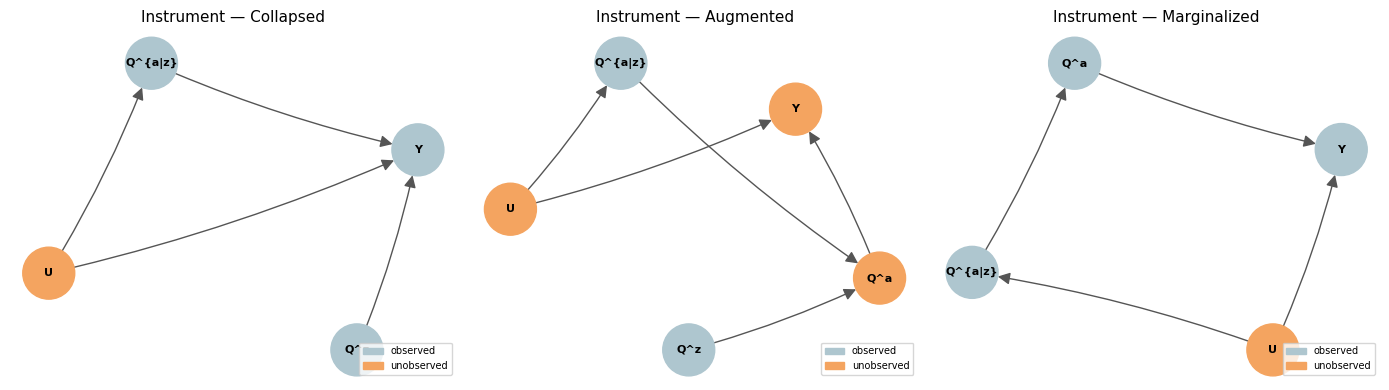

In [17]:
# ── 3.3  Collapse → Augment → Marginalize ────────────────────────────────────
inst_cgm     = collapse(hscm_inst)
inst_aug_cgm = augment_collapsed_model(inst_cgm, 'Q^a', {'Q^z', 'Q^{a|z}'})
inst_mar_cgm = marginalize_augmented_model(inst_aug_cgm, 'Y', {'Q^z'})
inst_mar_cgm.unobserved_variables = {'U'}

print('Collapsed    nodes:', sorted(inst_cgm.dag.nodes))
print('Collapsed    edges:', sorted(inst_cgm.dag.edges))
print('Augmented    nodes:', sorted(inst_aug_cgm.dag.nodes))
print('Augmented    edges:', sorted(inst_aug_cgm.dag.edges))
print('Marginalized nodes:', sorted(inst_mar_cgm.dag.nodes))
print('Marginalized edges:', sorted(inst_mar_cgm.dag.edges))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_cgm(inst_cgm,     'Instrument — Collapsed',    axes[0], highlight_unobs={'U'})
plot_cgm(inst_aug_cgm, 'Instrument — Augmented',    axes[1], highlight_unobs={'U'})
plot_cgm(inst_mar_cgm, 'Instrument — Marginalized', axes[2], highlight_unobs={'U'})
plt.tight_layout(); plt.show()

In [18]:
# ── 3.4  Do-calculus identification ──────────────────────────────────────────
result_inst = identify_effect(
    inst_mar_cgm, Y={'Y'}, X={'Q^a'}, unobserved={'U'}
)
print('Identifiable:', result_inst.identifiable)
if result_inst.formula_latex:
    print('Formula:', result_inst.formula_latex)

Identifiable: True
Formula: \sum_{Qa_z}{P\left(Qa_z\right) \cdot P\left(Y\mid Qa,Qa_z\right)}


In [19]:
# ── 3.5  True ATE via Monte Carlo ────────────────────────────────────────────
# Under do(Q^a=a): Y_i | do(Q^a=a) ~ Bern(sigmoid(3*a + 1.5*U_i - 1.5))
U_mc_inst = rng.beta(2, 2, 200_000)
true_ey1_inst = float(np.mean(sigmoid(3*1 + 1.5*U_mc_inst - 1.5)))
true_ey0_inst = float(np.mean(sigmoid(3*0 + 1.5*U_mc_inst - 1.5)))
true_ate_inst = true_ey1_inst - true_ey0_inst
print(f'True E[Y|do(A=1)] = {true_ey1_inst:.4f}')
print(f'True E[Y|do(A=0)] = {true_ey0_inst:.4f}')
print(f'True ATE          = {true_ate_inst:.4f}')

True E[Y|do(A=1)] = 0.9007
True E[Y|do(A=0)] = 0.3252
True ATE          = 0.5756


In [ ]:
# ── 3.6  Estimate ATE ────────────────────────────────────────────────────────

# Method A: standalone IV estimator (explicit call)
ate1_inst_s = estimate_instrument_ate(
    Y_inst, Q_a_inst, Q_az_inst, intervention_value=1.0, family_outcome='bernoulli'
)
ate0_inst_s = estimate_instrument_ate(
    Y_inst, Q_a_inst, Q_az_inst, intervention_value=0.0, family_outcome='bernoulli'
)
effect_inst_s = ate1_inst_s - ate0_inst_s

# Method B: full pipeline via estimate_causal_effect
# The identified formula \sum_{Qa_z} P(Qa_z)·P(Y|Qa,Qa_z) is parsed by
# _analyze_formula → sum_var 'Qa_z' matches a[_|]z → pattern='instrument' →
# _pyagrum_to_paper('Qa_z') = 'Q^{a|z}' → found directly in data dict →
# dispatches to estimate_instrument_ate (Appendix D.3).
# Requires 1D Y, Q^a, and Q^{a|z} arrays.
data_inst = {
    'Y':       Y_inst,      # (200,)  unit-level outcome
    'Q^a':     Q_a_inst,    # (200,)  per-unit mean(A)
    'Q^{a|z}': Q_az_inst,   # (200,)  compliance rate (proxy for U via Q^z)
}

ate1_inst_f = estimate_causal_effect(
    result_inst, data=data_inst, intervention={'Q^a': 1.0},
    distribution_families={'Y': 'bernoulli'},
)
ate0_inst_f = estimate_causal_effect(
    result_inst, data=data_inst, intervention={'Q^a': 0.0},
    distribution_families={'Y': 'bernoulli'},
)
effect_inst_f = ate1_inst_f - ate0_inst_f

hdr = '{:<30} {:>12} {:>12} {:>10} {:>10}'.format('Method','E[Y|do(1)]','E[Y|do(0)]','ATE','Error')
sep = '-' * 78
print('INSTRUMENT — ATE estimation results')
print(hdr); print(sep)
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10}'.format('True (MC)', true_ey1_inst, true_ey0_inst, true_ate_inst, '—'))
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10.4f}'.format('Standalone', ate1_inst_s, ate0_inst_s, effect_inst_s, abs(effect_inst_s-true_ate_inst)))
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10.4f}'.format('estimate_causal_effect', ate1_inst_f, ate0_inst_f, effect_inst_f, abs(effect_inst_f-true_ate_inst)))

---
## 4 — Summary

All three HCM models estimated; true ATE computed by Monte Carlo over the unobserved confounder U.

In [21]:
import pandas as pd

rows = [
    {'Model': 'CONFOUNDER',
     'True ATE':         round(true_ate_conf, 4),
     'Standalone ATE':   round(effect_conf_s, 4),
     'Standalone Error': round(abs(effect_conf_s - true_ate_conf), 4),
     'Formula ATE':      round(effect_conf_f, 4),
     'Formula Error':    round(abs(effect_conf_f - true_ate_conf), 4)},
    {'Model': 'C&I',
     'True ATE':         round(true_ate_ci, 4),
     'Standalone ATE':   round(effect_ci_s, 4),
     'Standalone Error': round(abs(effect_ci_s - true_ate_ci), 4),
     'Formula ATE':      round(effect_ci_f, 4),
     'Formula Error':    round(abs(effect_ci_f - true_ate_ci), 4)},
    {'Model': 'INSTRUMENT',
     'True ATE':         round(true_ate_inst, 4),
     'Standalone ATE':   round(effect_inst_s, 4),
     'Standalone Error': round(abs(effect_inst_s - true_ate_inst), 4),
     'Formula ATE':      round(effect_inst_f, 4),
     'Formula Error':    round(abs(effect_inst_f - true_ate_inst), 4)},
]

df = pd.DataFrame(rows).set_index('Model')
print(df.to_string())

            True ATE  Standalone ATE  Standalone Error  Formula ATE  Formula Error
Model                                                                             
CONFOUNDER    0.3152          0.2933            0.0218       0.2933         0.0218
C&I           0.3799          0.2921            0.0878       0.2921         0.0878
INSTRUMENT    0.5756          0.3715            0.2041       0.3715         0.2041


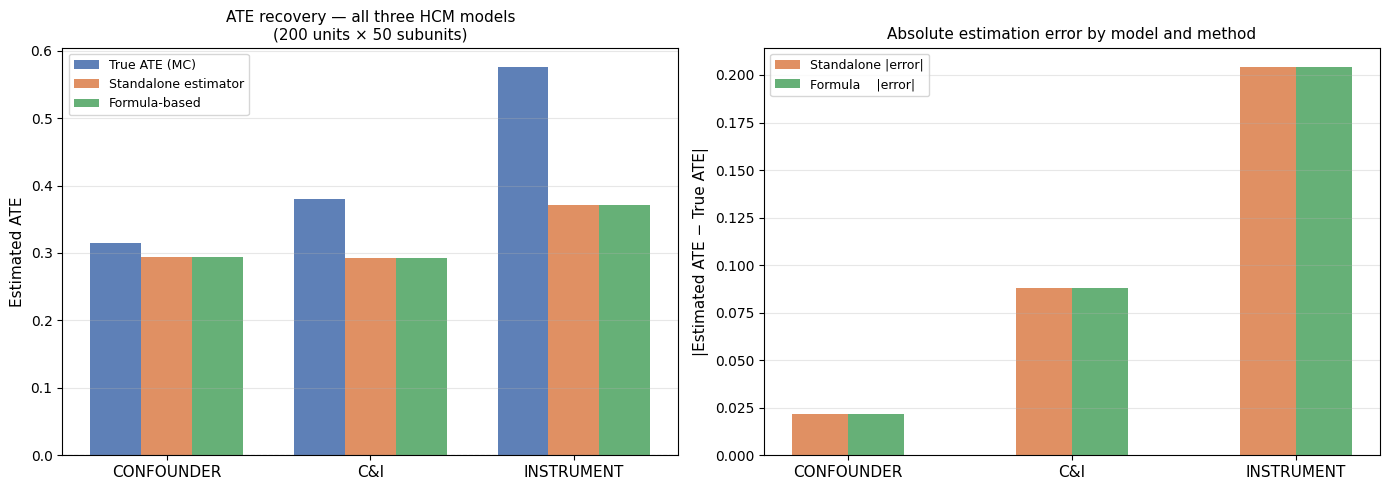

In [22]:
models     = ['CONFOUNDER', 'C&I', 'INSTRUMENT']
true_ates  = [true_ate_conf, true_ate_ci,   true_ate_inst]
stand_ates = [effect_conf_s, effect_ci_s,   effect_inst_s]
form_ates  = [effect_conf_f, effect_ci_f,   effect_inst_f]

x, w = np.arange(len(models)), 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ATE comparison
ax = axes[0]
ax.bar(x-w,   true_ates,   w, label='True ATE (MC)',       color='#4c72b0', alpha=0.9)
ax.bar(x,     stand_ates,  w, label='Standalone estimator', color='#dd8452', alpha=0.9)
ax.bar(x+w,   form_ates,   w, label='Formula-based',        color='#55a868', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Estimated ATE', fontsize=11)
ax.set_title(f'ATE recovery — all three HCM models\n({N_UNITS} units × {N_SUB} subunits)', fontsize=11)
ax.legend(fontsize=9); ax.axhline(0, color='gray', lw=0.8, ls='--'); ax.grid(axis='y', alpha=0.3)

# Absolute errors
ax2 = axes[1]
stand_err = [abs(s-t) for s, t in zip(stand_ates, true_ates)]
form_err  = [abs(f-t) for f, t in zip(form_ates,  true_ates)]
ax2.bar(x-w/2, stand_err, w, label='Standalone |error|', color='#dd8452', alpha=0.9)
ax2.bar(x+w/2, form_err,  w, label='Formula    |error|', color='#55a868', alpha=0.9)
ax2.set_xticks(x); ax2.set_xticklabels(models, fontsize=11)
ax2.set_ylabel('|Estimated ATE − True ATE|', fontsize=11)
ax2.set_title('Absolute estimation error by model and method', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()